<a href="https://colab.research.google.com/github/rotoncsedu/Computer-Vision/blob/main/MobileNet_and_Efficient_Net_for_Emotion_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [2]:
! pip install -q kaggle
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"mdalimranroton","key":"77970a92a73d89c8164499b9d653fd8b"}'}

In [3]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/

In [5]:
!chmod 600 /root/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d muhammadhananasghar/human-emotions-datasethes --unzip

Dataset URL: https://www.kaggle.com/datasets/muhammadhananasghar/human-emotions-datasethes
License(s): unknown
100% 309M/309M [00:01<00:00, 256MB/s]



In [6]:
train_dir = "/content/Emotions Dataset/Emotions Dataset/train"
val_dir = "/content/Emotions Dataset/Emotions Dataset/test"
CLASS_NAME = ["angry", "happy", "sad"]
CONFIGURATION ={
    "BATCH_SIZE" : 32,
    "IMAGE_SIZE" : 380,
    "CHANNELS" : 3,
    "H_EPOCHS" : 10,
    "LEARNING_RATE" : 0.0001,
    "DROPOUT_RATE" : 0.2,
    "REGULARIZATION_RATE" : 0.001,
    "N_FILTER" : 16,
    "KERNEL_SIZE" : 3,
    "POOL_SIZE" : 2,
    "N_STRIDES" : 1,
    "N_PADDING" : "same",
    "N_DENSE_1" : 100,
    "N_DENSE_2" : 10,
    "N_OUTPUT" : 3,
}

In [7]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    class_names=CLASS_NAME,
    batch_size=32,
    image_size=(CONFIGURATION['IMAGE_SIZE'],CONFIGURATION['IMAGE_SIZE']),
    shuffle=True,
    seed=99,
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    class_names=CLASS_NAME,
    batch_size=32,
    image_size=(CONFIGURATION['IMAGE_SIZE'],CONFIGURATION['IMAGE_SIZE']),
    shuffle=True,
    seed=99,
)

Found 6799 files belonging to 3 classes.
Found 2278 files belonging to 3 classes.


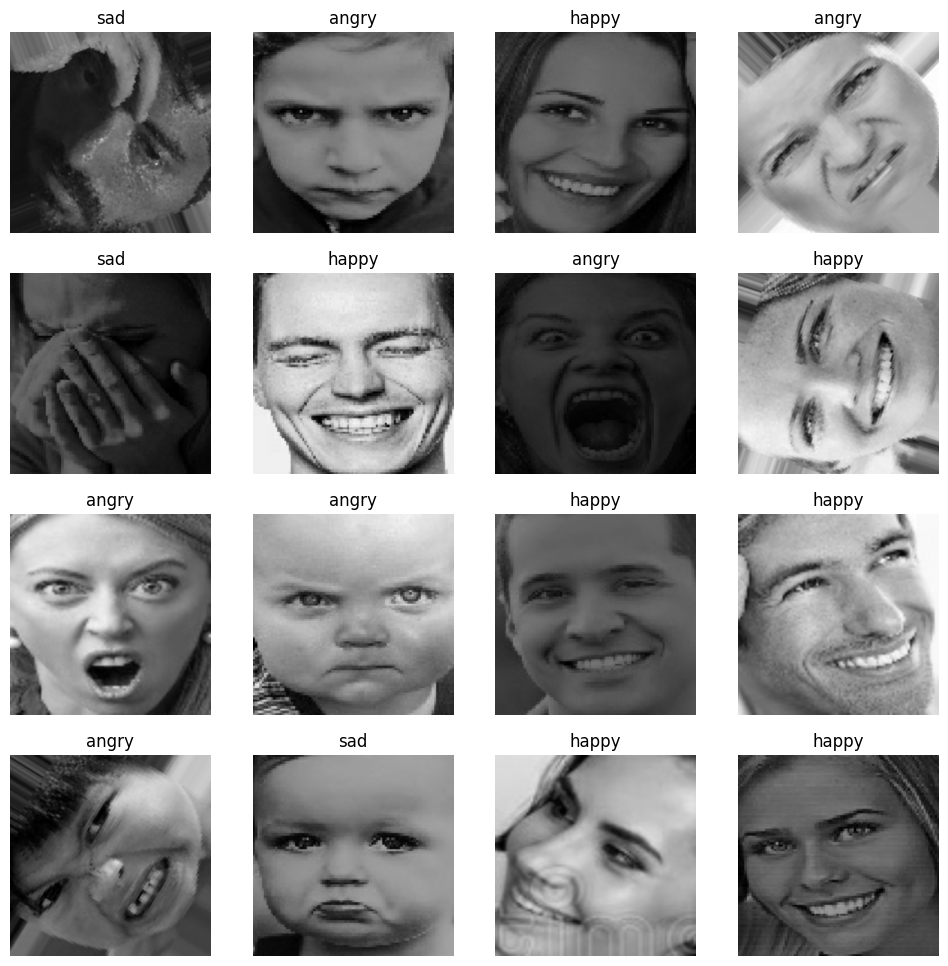

In [8]:
plt.figure(figsize=(12, 12))
for images, labels in train_dataset.take(1):
  for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8")/255)
    plt.title(CLASS_NAME[np.argmax(labels[i])])
    plt.axis("off")

In [9]:
augment_layers = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [10]:
def augment_layer(image, label):
  return augment_layers(image, training = True), label

In [11]:
traning_dataset = (
    train_dataset
    .cache()
    .shuffle(1000)
    .map(augment_layer, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)
val_dataset = (
    val_dataset
    .cache()
    .shuffle(1000)
    .prefetch(buffer_size=tf.data.AUTOTUNE)
)

In [12]:
for i in train_dataset.take(1):
  print(i)

(<tf.Tensor: shape=(32, 380, 380, 3), dtype=float32, numpy=
array([[[[ 25.       ,  25.       ,  25.       ],
         [ 25.       ,  25.       ,  25.       ],
         [ 25.       ,  25.       ,  25.       ],
         ...,
         [102.894775 , 102.894775 , 102.894775 ],
         [100.536865 , 100.536865 , 100.536865 ],
         [ 99.       ,  99.       ,  99.       ]],

        [[ 24.61579  ,  24.61579  ,  24.61579  ],
         [ 24.61579  ,  24.61579  ,  24.61579  ],
         [ 24.61579  ,  24.61579  ,  24.61579  ],
         ...,
         [103.6733   , 103.6733   , 103.6733   ],
         [101.54188  , 101.54188  , 101.54188  ],
         [100.15263  , 100.15263  , 100.15263  ]],

        [[ 24.026316 ,  24.026316 ,  24.026316 ],
         [ 24.026316 ,  24.026316 ,  24.026316 ],
         [ 24.026316 ,  24.026316 ,  24.026316 ],
         ...,
         [104.86776  , 104.86776  , 104.86776  ],
         [103.08381  , 103.08381  , 103.08381  ],
         [101.92105  , 101.92105  , 101.9210

In [13]:
from tensorflow.keras.layers import Resizing, Rescaling

resize_rescale_layers = tf.keras.Sequential([
       Resizing(CONFIGURATION["IMAGE_SIZE"], CONFIGURATION["IMAGE_SIZE"]),
       Rescaling(1./255),
])

In [14]:
train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 380, 380, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 3), dtype=tf.float32, name=None))>

In [15]:
val_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 380, 380, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 3), dtype=tf.float32, name=None))>

In [16]:
import matplotlib.pyplot as plt
def plot_loss_curves(history):
  accuracy = history.history["accuracy"]
  val_accuracy = history.history["val_accuracy"]
  loss = history.history["loss"]
  val_loss = history.history["val_loss"]
  epochs = range(1, len(accuracy)+1)
  plt.plot(epochs, accuracy, "b", label="Training accuracy")
  plt.plot(epochs, val_accuracy, "r", label="Validation accuracy")
  plt.title("Training and validation accuracy")
  plt.legend()
  plt.figure()
  plt.plot(epochs, loss, "b", label="Training loss")
  plt.plot(epochs, val_loss, "r", label="Validation loss")
  plt.title("Training and validation loss")
  plt.legend()
  plt.show()

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB4

In [18]:
IMG_SIZE = 380
NUM_CLASSES = 3

base_model = EfficientNetB4(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [19]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 380, 380,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 380, 380,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 380, 380,  │          7 │ rescaling_1[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 380, 380,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 381, 381,  │          0 │ rescaling_2[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 190, 190,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 190, 190,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 190, 190,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 190, 190,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 190, 190,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 190, 190,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 190, 190,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 190, 190,  │      1,152 │ block1a_se_excit

 Total params: 18,600,546 (70.96 MB)

 Trainable params: 923,139 (3.52 MB)

 Non-trainable params: 17,677,407 (67.43 MB)

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 217s 732ms/step - accuracy: 0.6379 - loss: 1.2671 - val_accuracy: 0.7283 - val_loss: 0.6398
Epoch 2/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 82s 363ms/step - accuracy: 0.7255 - loss: 0.7391 - val_accuracy: 0.7524 - val_loss: 0.6044
Epoch 3/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 77s 363ms/step - accuracy: 0.7689 - loss: 0.5908 - val_accuracy: 0.7713 - val_loss: 0.5812
Epoch 4/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 77s 361ms/step - accuracy: 0.7823 - loss: 0.5307 - val_accuracy: 0.7937 - val_loss: 0.5184
Epoch 5/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 77s 364ms/step - accuracy: 0.7960 - loss: 0.5036 - val_accuracy: 0.7976 - val_loss: 0.5269
Epoch 6/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 77s 363ms/step - accuracy: 0.8147 - loss: 0.4653 - val_accuracy: 0.8042 - val_loss: 0.5064
Epoch 7/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 77s 363ms/step - accuracy: 0.8066 - loss: 0.4736 - val_accuracy: 0.8055 - val_loss: 0.5116
Epoch 8/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 77s 363ms/step - accuracy: 0.8170 - loss: 

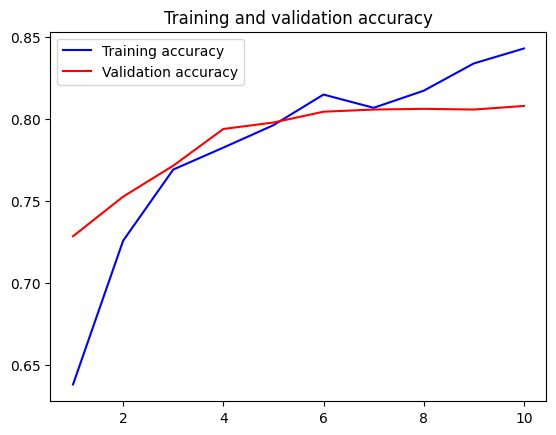

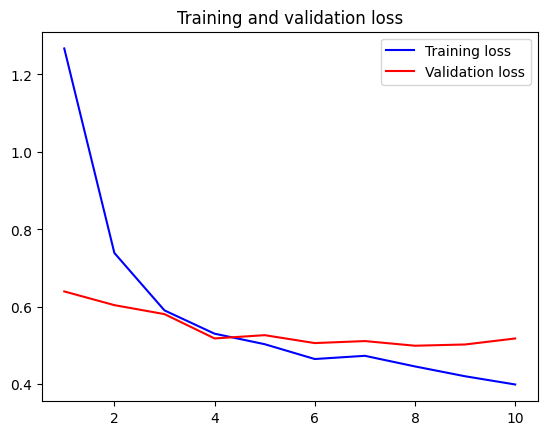

In [23]:
plot_loss_curves(history)

In [24]:
model.evaluate(val_dataset)

72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 272ms/step - accuracy: 0.8077 - loss: 0.5183


[0.5183107852935791, 0.8077260851860046]

Fine Tuning

In [20]:
for layer in base_model.layers:
    print(layer.name)

input_layer_1
rescaling_1
normalization
rescaling_2
stem_conv_pad
stem_conv
stem_bn
stem_activation
block1a_dwconv
block1a_bn
block1a_activation
block1a_se_squeeze
block1a_se_reshape
block1a_se_reduce
block1a_se_expand
block1a_se_excite
block1a_project_conv
block1a_project_bn
block1b_dwconv
block1b_bn
block1b_activation
block1b_se_squeeze
block1b_se_reshape
block1b_se_reduce
block1b_se_expand
block1b_se_excite
block1b_project_conv
block1b_project_bn
block1b_drop
block1b_add
block2a_expand_conv
block2a_expand_bn
block2a_expand_activation
block2a_dwconv_pad
block2a_dwconv
block2a_bn
block2a_activation
block2a_se_squeeze
block2a_se_reshape
block2a_se_reduce
block2a_se_expand
block2a_se_excite
block2a_project_conv
block2a_project_bn
block2b_expand_conv
block2b_expand_bn
block2b_expand_activation
block2b_dwconv
block2b_bn
block2b_activation
block2b_se_squeeze
block2b_se_reshape
block2b_se_reduce
block2b_se_expand
block2b_se_excite
block2b_project_conv
block2b_project_bn
block2b_drop
block2b

In [21]:
base_model.trainable = False
for layer in base_model.layers:
    if "block7" in layer.name or "top" in layer.name:
        layer.trainable = True

In [22]:
print("Trainable layers:")
for layer in base_model.layers:
    if layer.trainable:
        print(layer.name)

Trainable layers:
block7a_expand_conv
block7a_expand_bn
block7a_expand_activation
block7a_dwconv
block7a_bn
block7a_activation
block7a_se_squeeze
block7a_se_reshape
block7a_se_reduce
block7a_se_expand
block7a_se_excite
block7a_project_conv
block7a_project_bn
block7b_expand_conv
block7b_expand_bn
block7b_expand_activation
block7b_dwconv
block7b_bn
block7b_activation
block7b_se_squeeze
block7b_se_reshape
block7b_se_reduce
block7b_se_expand
block7b_se_excite
block7b_project_conv
block7b_project_bn
block7b_drop
block7b_add
top_conv
top_bn
top_activation


In [23]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

fine_tune_model = models.Model(inputs=base_model.input, outputs=outputs)
fine_tune_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 380, 380,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 380, 380,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 380, 380,  │          7 │ rescaling_1[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 380, 380,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 381, 381,  │          0 │ rescaling_2[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 190, 190,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 190, 190,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 190, 190,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 190, 190,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 190, 190,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 190, 190,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 190, 190,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 190, 190,  │      1,152 │ block1a_se_excit

 Total params: 18,600,546 (70.96 MB)

 Trainable params: 6,199,543 (23.65 MB)

 Non-trainable params: 12,401,003 (47.31 MB)

In [24]:
fine_tune_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
fine_tune_history = fine_tune_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 255s 840ms/step - accuracy: 0.7150 - loss: 0.9777 - val_accuracy: 0.8240 - val_loss: 0.7580
Epoch 2/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 86s 405ms/step - accuracy: 0.7936 - loss: 0.6502 - val_accuracy: 0.8358 - val_loss: 0.5737
Epoch 3/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 86s 405ms/step - accuracy: 0.8556 - loss: 0.3952 - val_accuracy: 0.8560 - val_loss: 0.3764
Epoch 4/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 86s 404ms/step - accuracy: 0.8891 - loss: 0.2849 - val_accuracy: 0.8617 - val_loss: 0.3704
Epoch 5/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 86s 402ms/step - accuracy: 0.9048 - loss: 0.2548 - val_accuracy: 0.8534 - val_loss: 0.4462
Epoch 6/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 86s 403ms/step - accuracy: 0.8938 - loss: 0.4104 - val_accuracy: 0.8613 - val_loss: 0.5106
Epoch 7/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 86s 403ms/step - accuracy: 0.9006 - loss: 0.3091 - val_accuracy: 0.8718 - val_loss: 0.6376
Epoch 8/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 86s 405ms/step - accuracy: 0.9191 - loss: 

In [26]:
fine_tune_model.evaluate(val_dataset)

72/72 ━━━━━━━━━━━━━━━━━━━━ 19s 262ms/step - accuracy: 0.8802 - loss: 0.4820


[0.4819587171077728, 0.880158007144928]

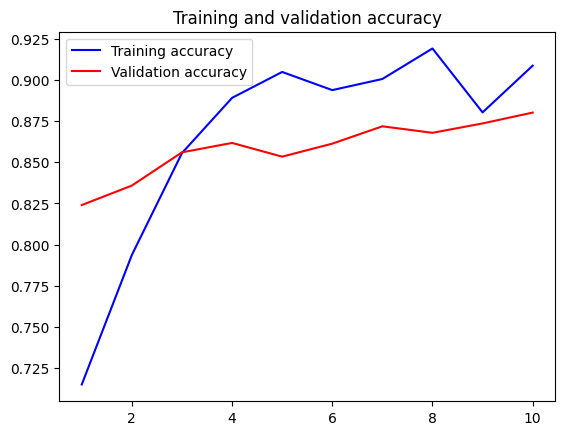

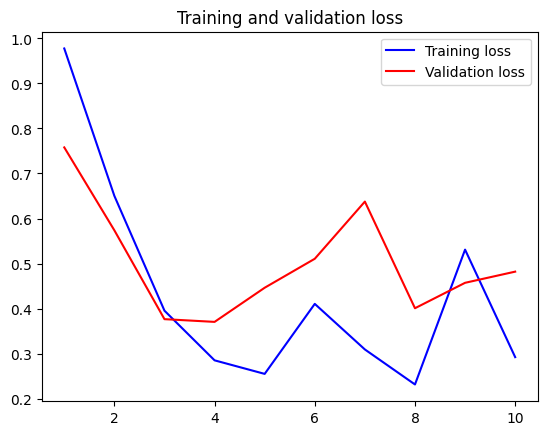

In [27]:
plot_loss_curves(fine_tune_history)

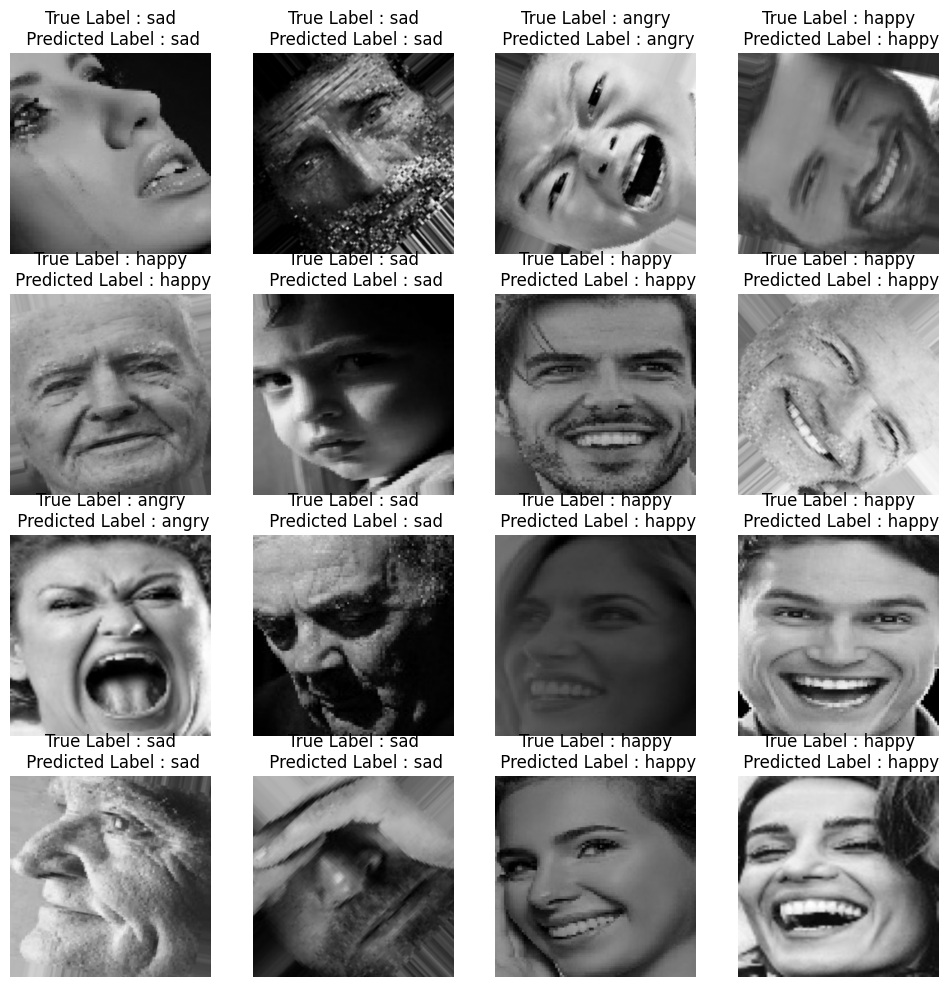

In [28]:
plt.figure(figsize=(12, 12))
for images, labels in val_dataset.take(1):
  for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8")/255)
    plt.title("True Label : " + CLASS_NAME[np.argmax(labels[i])] + "\n" + " Predicted Label : " + CLASS_NAME[np.argmax(fine_tune_model(tf.expand_dims(images[i],axis = 0)))])
    plt.axis("off")

Transfer Learning Mobile Net

In [30]:
backbone_mobile_net = tf.keras.applications.mobilenet_v2.MobileNetV2(
    include_top = False,
    weights='imagenet',
    input_shape=(CONFIGURATION['IMAGE_SIZE'], CONFIGURATION['IMAGE_SIZE'], 3),
    )

/tmp/ipykernel_21589/3268269822.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone_mobile_net = tf.keras.applications.mobilenet_v2.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
backbone_mobile_net = tf.keras.applications.mobilenet_v2.MobileNetV2(
    include_top = False,
    weights='imagenet',
    input_shape=(CONFIGURATION['IMAGE_SIZE'], CONFIGURATION['IMAGE_SIZE'], 3),
    )

/tmp/ipykernel_21589/3268269822.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone_mobile_net = tf.keras.applications.mobilenet_v2.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [32]:
backbone_mobile_net.trainable = False

In [34]:
x = backbone_mobile_net.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(CONFIGURATION['N_OUTPUT'], activation='softmax')(x)

fine_tune_mobilenet_model = models.Model(inputs=backbone_mobile_net.input, outputs=outputs)
fine_tune_mobilenet_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 380, 380,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 190, 190,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 190, 190,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 190, 190,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 190, 190,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 190, 190,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 190, 190,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 190, 190,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 190, 190,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 190, 190,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 190, 190,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 190, 190,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 191, 191,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 95, 95,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 95, 95,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 95, 95,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 95, 95,    │      2,304 │ block_1_depthwis

 Total params: 2,920,515 (11.14 MB)

 Trainable params: 659,971 (2.52 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [35]:
fine_tune_mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [36]:
fine_tune_mobilenet_history = fine_tune_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 88s 409ms/step - accuracy: 0.9340 - loss: 0.1719 - val_accuracy: 0.8727 - val_loss: 0.4836
Epoch 2/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 87s 406ms/step - accuracy: 0.9409 - loss: 0.1714 - val_accuracy: 0.8793 - val_loss: 0.4293
Epoch 3/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 87s 406ms/step - accuracy: 0.9444 - loss: 0.1425 - val_accuracy: 0.8775 - val_loss: 0.4578
Epoch 4/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 86s 406ms/step - accuracy: 0.9451 - loss: 0.1416 - val_accuracy: 0.8709 - val_loss: 0.4834
Epoch 5/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 86s 405ms/step - accuracy: 0.9288 - loss: 0.3421 - val_accuracy: 0.8543 - val_loss: 0.7650
Epoch 6/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 86s 405ms/step - accuracy: 0.9237 - loss: 0.2372 - val_accuracy: 0.8622 - val_loss: 0.6700
Epoch 7/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 86s 404ms/step - accuracy: 0.9378 - loss: 0.2046 - val_accuracy: 0.8714 - val_loss: 0.5116
Epoch 8/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 86s 405ms/step - accuracy: 0.9479 - loss: 0

In [37]:
fine_tune_mobilenet_model.evaluate(val_dataset)

72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 259ms/step - accuracy: 0.4399 - loss: 1.1323


[1.132300853729248, 0.439859539270401]

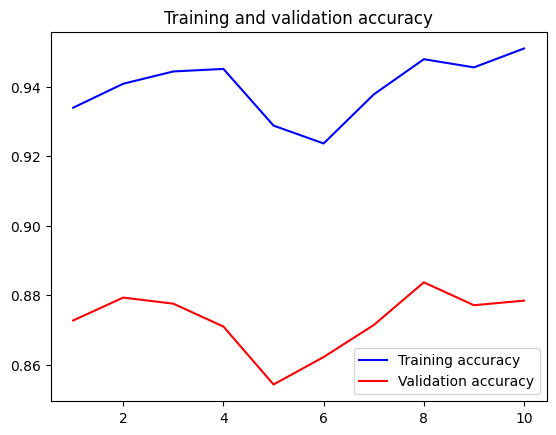

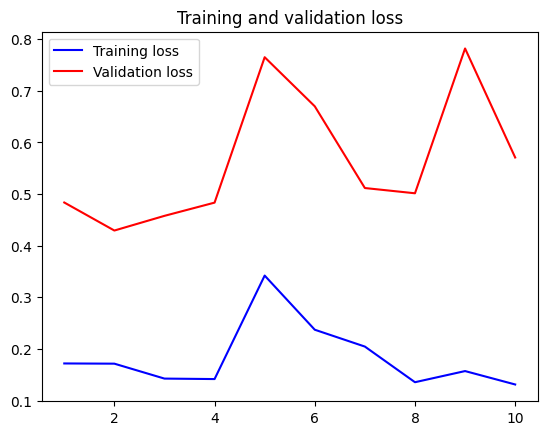

In [38]:
plot_loss_curves(fine_tune_mobilenet_history)

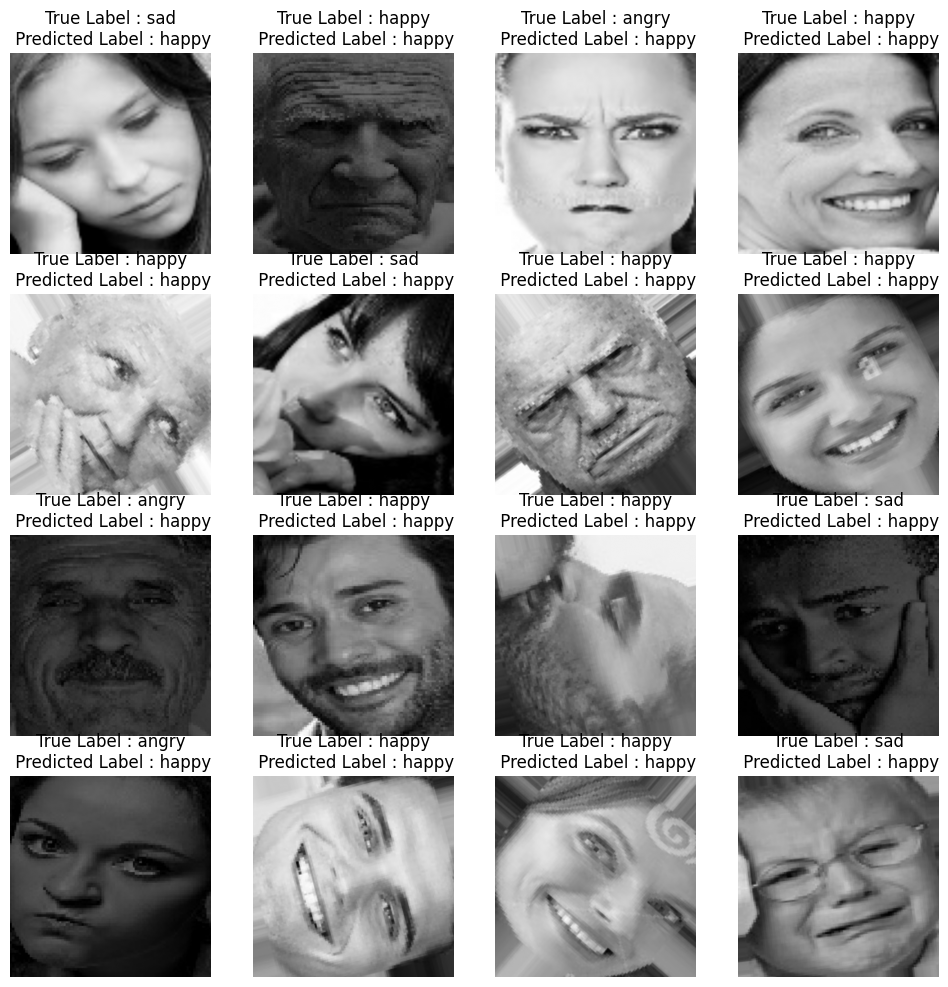

In [39]:
plt.figure(figsize=(12, 12))
for images, labels in val_dataset.take(1):
  for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(images[i].numpy().astype("uint8")/255)
    plt.title("True Label : " + CLASS_NAME[np.argmax(labels[i])] + "\n" + " Predicted Label : " + CLASS_NAME[np.argmax(fine_tune_mobilenet_model(tf.expand_dims(images[i],axis = 0)))])
    plt.axis("off")